## Setup — run this first

This workshop uses helper modules from its GitHub repository (dataset loading, the
spiking-network models, and plotting utilities). The cell below **installs the
repository as a package** — along with external dependencies such as `aeon` (used to
download the dataset) — so that `import snn_workshop` works on Google Colab. PyTorch,
NumPy and Matplotlib are already available on Colab.

> Running locally from a clone instead? Use `pip install -e .` in the repo root; the
> cell below detects that `snn_workshop` is already importable and skips the install.

In [1]:
# Install the workshop package (and its dependencies, e.g. aeon) if needed.
import importlib.util, subprocess, sys

REPO_URL = "https://github.com/rwvos/bisccits-snn-workshop.git"  # workshop repository
REPO_REF = "main"   # branch, tag, or commit to install (e.g. "main", "dev", "v0.1.0")

if importlib.util.find_spec("snn_workshop") is None:
    spec = f"git+{REPO_URL}@{REPO_REF}"
    print(f"Installing snn_workshop (+ aeon and other dependencies) from {spec} ...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", spec],
        check=True,
    )
    print("Installation complete.")
else:
    print("snn_workshop already importable — skipping install.")

Installing snn_workshop (+ aeon and other dependencies) from git+https://github.com/rwvos/bisccits-snn-workshop.git@main ...
Installation complete.


# Chapter 1 — Defining a Spiking Neural Network

**BISCCITS workshop · Spiking Neural Networks**

Welcome! Over three chapters we will go from a single biologically-inspired neuron to a
*trained, efficient* spiking neural network (SNN), and we will measure exactly where
that efficiency comes from.

- **Chapter 1 (this one) — Defining SNNs.** What equations govern a spiking neuron,
  and how do we write them down so a computer can simulate them?
- **Chapter 2 — Training SNNs.** How do we train a network of spiking neurons with
  the same machinery (backpropagation) used for ordinary deep nets, despite the spike
  being non-differentiable?
- **Chapter 3 — Evaluating SNNs.** Once trained, what does the network actually do at
  inference, and how much cheaper is it than a conventional network?
  **Bonus — Can we make it faster?**

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/roadmap.png?raw=1" width="820"/></div>

This workshop assumes you are slightly comfortable with the *biology* of neurons but not necessarily
with machine learning and PyTorch.

> **Objective of Chapter 1.** Implement a leaky integrate-and-fire (LIF) neuron from
> its equations, see its dynamics, and understand the trick that will later let us
> train spiking networks: the *surrogate gradient*.

## From a biological neuron to a leaky integrate-and-fire model

A biological neuron integrates incoming current in its membrane potential. The membrane leaks
charge over time, so it behaves like a **low-pass filter**: steady input charges it
up, and when the input stops it relaxes back toward rest. When the membrane potential
crosses a **threshold**, the neuron emits a **spike** and its potential is **reset**.

The simplest model capturing this is the **leaky integrate-and-fire (LIF)** neuron.
In continuous time:

$$\tau_\text{mem}\,\frac{dV(t)}{dt} = -V(t) + I(t), \qquad \text{spike when } V \ge V_\text{thr},\ \text{then } V \leftarrow V_\text{reset}.$$

For simulation (and for PyTorch later) we use the **discrete-time** version. With a
step `dt` and decay `beta = exp(-dt / tau_mem)`:

$$
\begin{aligned}
V[t] &= \beta\, V[t-1] + (1-\beta)\, I[t] && \text{(leaky integration / low-pass filter)}\\
S[t] &= \begin{cases}1 & V[t] \ge V_\text{thr}\\ 0 & \text{otherwise}\end{cases} && \text{(threshold $\rightarrow$ spike)}\\
V[t] &\leftarrow V_\text{reset} \quad \text{if } S[t]=1 && \text{(hard reset)}
\end{aligned}
$$

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/ch1_lif_neuron.png?raw=1" width="430"/></div>

<div align="center"><em>The LIF neuron: an input current charges the membrane, which leaks by β each step; on crossing the threshold it emits a spike and hard-resets.</em></div>

`beta` controls memory: `beta -> 1` means a long membrane time constant (slow,
strongly smoothing), `beta -> 0` means the neuron almost instantly follows its input.

**Setup.** Import NumPy, PyTorch and Matplotlib, plus the workshop helpers, and fix a
random seed for reproducibility.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from snn_workshop import set_seed
from snn_workshop.viz import plot_membrane_dynamics

set_seed(0)

## Subtask 1 — Simulate one LIF neuron

We will integrate the three equations above over time, given an input current `I(t)`.
Note the order *inside* each timestep: **integrate → check threshold → reset**. The
reset applies to the state carried into the *next* step, which produces the
characteristic "sawtooth" membrane trace.

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/ch1_lif_unrolled.png?raw=1" width="520"/></div>

<div align="center"><em>The same neuron unrolled over time: one copy per timestep, with the membrane state carried forward along β — exactly the loop you will implement.</em></div>

**TASK.** Implement `lif_simulate(current, beta, threshold, v_reset)` returning the
membrane trace `mem` and the binary `spikes` array for an array `current` that contains input currents for a certain number of timesteps. Use a plain Python loop over
timesteps — clarity first; we move to tensors in Chapter 2.

In [3]:
def lif_simulate(current, beta, threshold=1.0, v_reset=0.0):
    """Simulate a single leaky integrate-and-fire (LIF) neuron over time.

    The neuron keeps a running membrane potential that, each step, leaks away a
    fraction of its previous value while taking up the input it receives. Whenever that
    potential reaches the firing threshold the neuron emits a spike and is immediately
    forced back down to its reset level. Because the reset only affects the state
    carried into the *next* step, a steadily driven neuron settles into a repeating
    charge-up-then-fire ("sawtooth") pattern.

    Parameters
    ----------
    current : np.ndarray, shape (T,), float
        Input current driving the neuron, one value per timestep (T timesteps total).
    beta : float in (0, 1)
        Membrane decay / leak factor. Values near 1 give a long memory (slow, heavily
        smoothed response); values near 0 make the neuron follow its input almost
        immediately.
    threshold : float, optional
        Membrane level at or above which the neuron fires (default 1.0).
    v_reset : float, optional
        Membrane level the neuron is forced to right after it fires (default 0.0).

    Returns
    -------
    mem : np.ndarray, shape (T,), float
        Membrane potential recorded at each timestep (the value reached at the instant
        of firing is the one stored for that step).
    spikes : np.ndarray, shape (T,), float
        Binary spike train: 1.0 on timesteps where the neuron fired, else 0.0.
    """
    current = np.asarray(current, dtype=np.float64)
    T = len(current)
    mem = np.zeros(T)
    spikes = np.zeros(T)

    v = v_reset  # membrane state carried between steps
    for t in range(T):
        # TODO: advance the neuron by one timestep. Update the carried membrane state so
        #       it leaks but takes up this step's input; decide whether it has reached
        #       threshold and emit a spike if so; store the membrane value into mem[t]
        #       and the spike into spikes[t]; and, if it fired, send the state back to
        #       its reset level before the next step.
        # YOUR CODE HERE
        v = beta*v + (1-beta)*current[t]
        if v >= threshold:
          s = 1.
          v = v_reset
        else:
          s = 0.
        mem[t] = v
        spikes[t] = s
    return mem, spikes

## Visualising the dynamics

We drive the neuron with a current that is off, then a constant pulse, then off
again, and plot three panels: the input current, the membrane potential (with the
threshold), and the output spikes. You should see the membrane charge up like a
low-pass filter, fire periodically while driven, reset after each spike, and decay
once the input stops.

*(No task — run this cell to produce the dynamics plot.)*

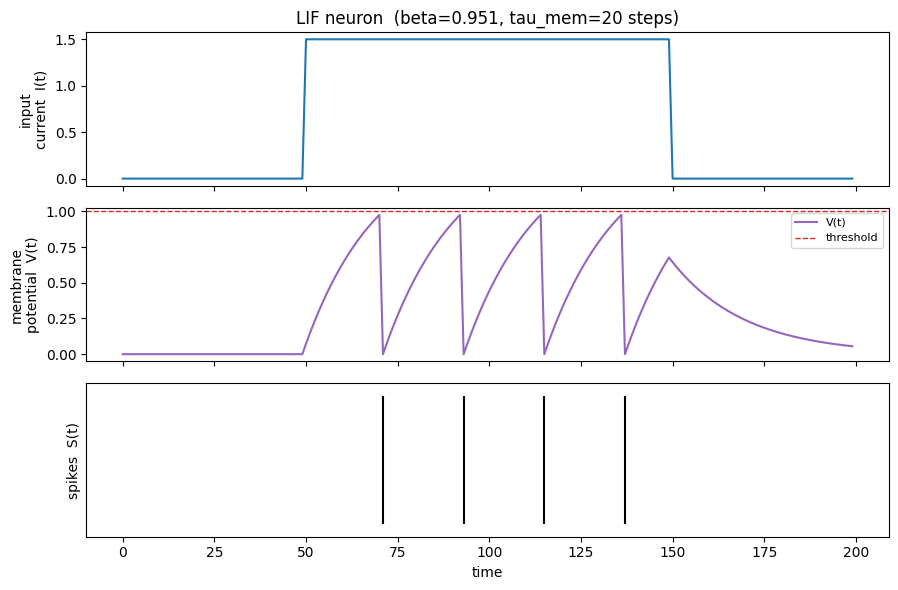

spike count: 4


In [4]:
T = 200
dt = 1.0

# A current that is off, then a constant drive, then off again.
current = np.zeros(T)
current[50:150] = 1.5

beta = np.exp(-dt / 20.0)  # tau_mem = 20 steps
mem, spikes = lif_simulate(current, beta=beta, threshold=1.0)

fig, _ = plot_membrane_dynamics(
    current, mem, spikes, threshold=1.0, dt=dt,
    title=f"LIF neuron  (beta={beta:.3f}, tau_mem=20 steps)",
)
plt.show()
print(f"spike count: {int(spikes.sum())}")

The slope of the charge-up and the firing frequency are both set by the membrane time
constant `tau_mem` (equivalently `beta`). A longer `tau_mem` integrates input over a
longer window — more smoothing, slower firing.

**TASK.** Drive the neuron with the *same* step current for several `tau_mem` values
(e.g. 5, 20, 60 steps) and compare the membrane traces and firing rates. Confirm that
a larger `tau_mem` charges more slowly and fires less often.

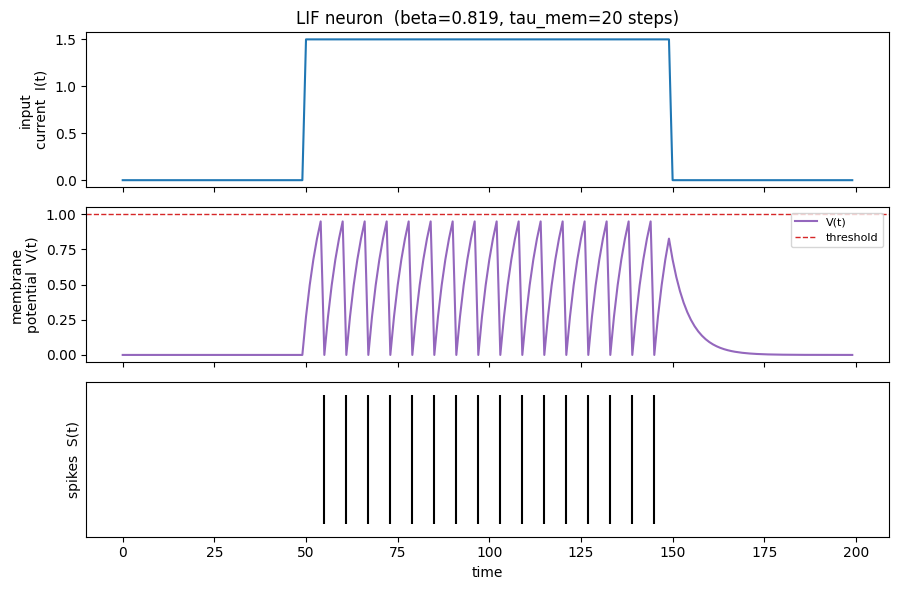

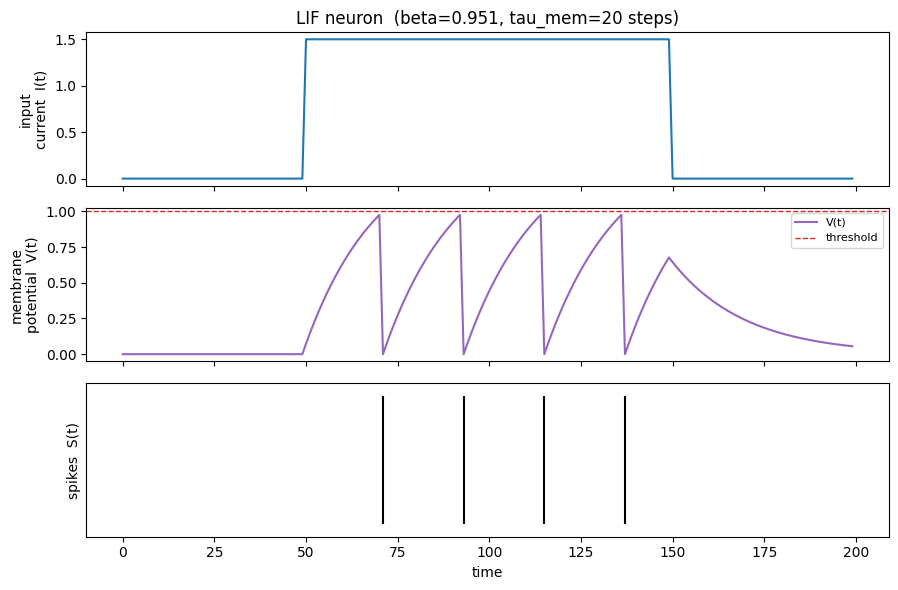

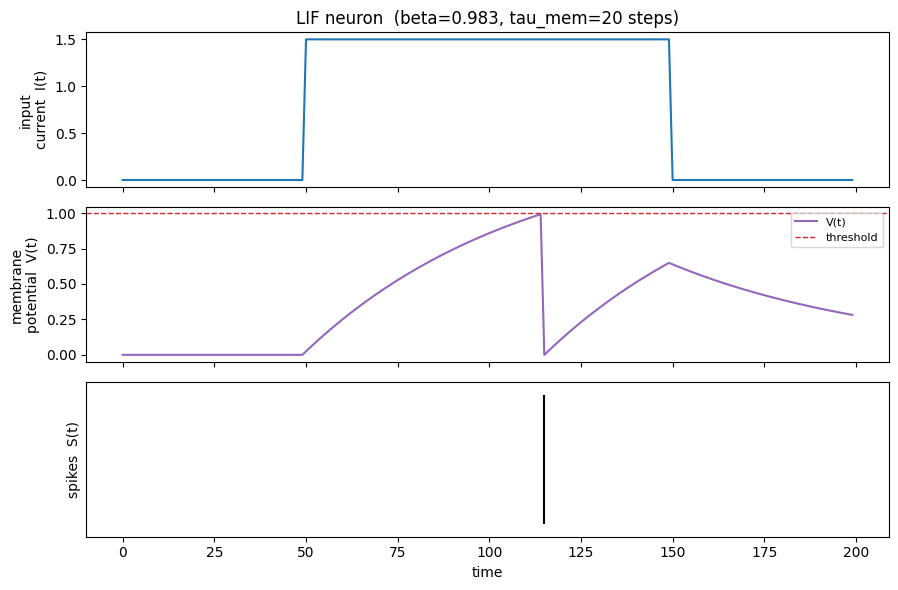

In [15]:
# Drive the neuron with the same step current for several values of tau_mem and
# compare both the membrane trace and the resulting firing rate.
taus = [5.0, 20.0, 60.0]
step = np.zeros(T)
step[20:] = 1.2

# TODO: for each membrane time constant in `taus`, convert it into the matching decay
#       factor and run the neuron on this same step current. Visualise how the time
#       constant shapes the dynamics: overlay the membrane traces (one line per time
#       constant) and show the corresponding spike times, and report each neuron's
#       firing rate so the slower-charging, less-frequently-firing trend is clear.
# YOUR CODE HERE
betas = np.exp(-dt/np.array(taus))
# print(betas)

for beta in betas:
  mem, spikes = lif_simulate(current, beta=beta, threshold=1.0)

  fig, _ = plot_membrane_dynamics(
      current, mem, spikes, threshold=1.0, dt=dt,
      title=f"LIF neuron  (beta={beta:.3f}, tau_mem=20 steps)",
  )

## The problem we will face in Chapter 2 — and the surrogate gradient

To *train* a network we need gradients: how does the loss change if we change a particular weight?
Gradients flow backward through every operation — but the spike is a **Heaviside step
function** of the membrane potential, and its derivative is **zero everywhere** (and
undefined exactly at the threshold). No gradient can flow through a spike.

The fix used throughout modern SNN training is the **surrogate gradient**: keep the
Heaviside step in the *forward* pass, but in the *backward* pass pretend the spike was a
smooth function (that approximates the spiking function). A common choice is the **derivative of a sigmoid**,
$\frac{d}{dV}\,\sigma\!\big(k\,(V - V_\text{thr})\big)$, a bump centred on the
threshold. The **slope** `k` controls its width: small `k` spreads gradient over a
wide range of membrane potentials (smooth but biased), large `k` concentrates it near
the threshold (sharp, closer to the true step function but with vanishing gradient away from
threshold).

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/ch1_heaviside_surrogate.png?raw=1" width="620"/></div>

<div align="center"><em>The spike (Heaviside) has a Dirac-δ derivative that carries no usable gradient; in the backward pass we substitute a smooth surrogate bump.</em></div>

**TASK.** Plot the Heaviside spike together with the sigmoid-derivative surrogate
gradient for a few slope values `k` (e.g. 1, 5, 25). Observe how the slope trades
gradient *width* against *sharpness*. We will plug exactly this surrogate into the
backward pass in Chapter 2.

[[<matplotlib.lines.Line2D at 0x7e34f095d4c0>],

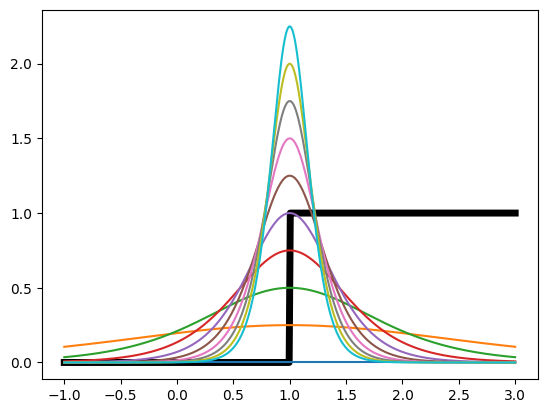

In [34]:
# A spike is an all-or-nothing event: the neuron either fires or it does not. Seen as a
# function of the membrane potential this is a hard step, and a hard step has no useful
# slope to learn from -- it is flat everywhere, with an instantaneous jump at the
# threshold. The plan we set up here is to keep the hard step for the forward behaviour
# but, when a gradient is later needed, substitute a smooth bump centred on the
# threshold so that some gradient can flow. A convenient bump is the slope (derivative)
# of a sigmoid; how wide or sharp it is depends on a `slope` parameter.
def heaviside(v, threshold=1.0):
    """Hard, all-or-nothing spike as a function of the membrane potential.

    Parameters
    ----------
    v : np.ndarray, shape (N,), float
        Membrane-potential values to evaluate.
    threshold : float, optional
        Firing threshold; the neuron is considered spiking once `v` reaches it
        (default 1.0).

    Returns
    -------
    spike : np.ndarray, shape (N,), float
        1.0 where the potential is at or above threshold, 0.0 elsewhere.
    """
    # TODO: return the all-or-nothing spike -- 1 wherever the membrane potential has
    #       reached the threshold and 0 everywhere else -- as a float array named
    #       `spike`.
    # YOUR CODE HERE
    spike = np.array(v > threshold).astype(int)
    return spike


def sigmoid_surrogate_grad(v, threshold=1.0, slope=5.0):
    """Smooth surrogate gradient used in place of the hard spike's (unusable) gradient.

    This is a smooth bump centred on the threshold: it is largest for membrane values
    right at the threshold and falls away on either side. The `slope` controls its
    shape -- a small slope gives a wide, gentle bump (gradient spread over many membrane
    values), a large slope a narrow, sharp one (gradient concentrated near threshold).

    Parameters
    ----------
    v : np.ndarray, shape (N,), float
        Membrane-potential values to evaluate.
    threshold : float, optional
        Centre of the bump, i.e. the firing threshold (default 1.0).
    slope : float, optional
        Sharpness of the bump (default 5.0): larger is narrower and taller.

    Returns
    -------
    grad : np.ndarray, shape (N,), float
        The surrogate-gradient value at each membrane potential.
    """
    # TODO: build the smooth bump by passing the (slope-scaled) distance of the membrane
    #       potential from the threshold through a sigmoid, then taking that sigmoid's
    #       own slope (its derivative). Scale it by `slope` so the bump's height matches
    #       its sharpness. Return the result as `grad`.
    # YOUR CODE HERE
    # grad = np.exp(-((v - threshold)/slope)**2)
    """d/dv of sigma(slope * (v - threshold)) -- a bump centred at the threshold."""
    x = slope * (v - threshold)
    sig = 1.0 / (1.0 + np.exp(-x))
    return slope * sig * (1.0 - sig)
    return grad


v = np.linspace(-1.0, 3.0, 400)
# v = np.linspace(-10, 10, 400)
# TODO: visualise both functions over this range of membrane potentials. Draw the hard
#       spike from heaviside(v), then overlay the surrogate bump from
#       sigmoid_surrogate_grad for a few different slopes so its sharpening is visible,
#       and mark where the threshold sits. A legend identifying each slope helps.
# YOUR CODE HERE
fig, ax = plt.subplots()
ax.plot(v, heaviside(v), lw=5, c='k')
[ax.plot(v, sigmoid_surrogate_grad(v, 1, slope)) for slope in np.arange(10)]
# ax.set_xlim(-10, 10)

### Recap

You implemented a LIF neuron, saw that it is a leaky low-pass integrator that fires
and resets, and met the surrogate gradient that makes spiking networks trainable.
**Next:** stack these neurons into layers, build a deep SNN, and train it on real
sensor data.

# Chapter 2 — Training a Spiking Neural Network

In Chapter 1 we built a single LIF neuron and met the surrogate gradient. Now we will:

1. stack LIF neurons into a **deep spiking network**,
2. train it on a real movement-sensor dataset with **backpropagation through time** using
   the surrogate gradient, and
3. **benchmark** it against a conventional MLP and a GRU.

> **Objective.** Train a 3-layer SNN end-to-end, and understand *why* the spike's
> non-differentiability is not an obstacle.

> **Bonus.** The optional bonus at the **end of the  notebook** rewrites the spike as
> *forward-gradient injection* — one differentiable expression — and uses `torch.compile`
> for a large speed-up. Get there if you have time.

## From one neuron to a deep network

A **layer** of LIF neurons is just many neurons in parallel. Each neuron receives a
weighted sum of the layer's inputs as its input current:

$$I^{(\ell)}[t] = W^{(\ell)} \, s^{(\ell-1)}[t], \qquad
  V^{(\ell)}[t] = \beta\,V^{(\ell)}[t-1] + I^{(\ell)}[t],$$

then thresholds and resets exactly as before, emitting a spike vector
$s^{(\ell)}[t]$. We stack three such layers. The network is **feedforward in space**
(layer $\ell$ feeds layer $\ell+1$) but **recurrent in time**: each neuron's membrane
carries state from one timestep to the next. *This temporal recurrence is the
"recurrent dynamics" of the SNN* — there are no explicit lateral weights here.

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/ch2_deep_snn.png?raw=1" width="700"/></div>

<div align="center"><em>From one neuron to a deep SNN: the Chapter-1 LIF unit, stacked into three layers (feedforward in space) feeding a linear readout.</em></div>

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/ch2_space_time_grid.png?raw=1" width="560"/></div>

<div align="center"><em>The same network unrolled in both axes: feedforward in space (↑) and recurrent in time through the membrane state (→).</em></div>

Our input is a length-$T$ multivariate time series. At every timestep we feed one
sample $x[t]$ into the first layer. After the last spiking layer we apply a linear
**readout** at each timestep and **average the logits over time**; the time-averaged
logits go into a standard **cross-entropy** classification loss.

> Why average over time? Each timestep produces a noisy, spike-driven vote for each
> class. Averaging integrates evidence across the whole sequence into one prediction.

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/ch2_readout_loss.png?raw=1" width="760"/></div>

<div align="center"><em>The readout: a linear layer per timestep produces logits, which are averaged over time and compared to the label with cross-entropy.</em></div>

**Setup.** Imports and device selection.

In [35]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from snn_workshop import set_seed, get_device
from snn_workshop.viz import (
    plot_training_curves, plot_metric_comparison, plot_method_grid,
    plot_runtime_bar, plot_confusion_matrices, plot_swing_3d,
)

set_seed(0)
DEVICE = get_device()
print("device:", DEVICE)

device: cpu


## Subtask 1 — The spike with a surrogate gradient

Recall the problem: the spike is a Heaviside step whose derivative is zero, so no
gradient flows. The classic fix in PyTorch is a **custom `autograd.Function`**: we
define the forward pass (the hard spike) and *override* the backward pass to use the
smooth surrogate from Chapter 1 (the derivative of a sigmoid).

This is the most explicit way to write it, and it makes the "different forward vs
backward" idea concrete. Its one drawback — which the optional bonus at the end of the
notebook addresses — is that a custom `autograd.Function` cannot be traced by
`torch.compile`.

**TASK.** Implement `SpikeFunction(torch.autograd.Function)`: `forward` returns
`(x >= 0).float()`; `backward` multiplies the incoming gradient by the
sigmoid-derivative surrogate `slope * σ(slope·x) · (1 − σ(slope·x))`. Wrap it in a
helper `spike_autograd(x, slope)`.

In [37]:
class SpikeFunction(torch.autograd.Function):
    """Hard spike in the forward pass; smooth surrogate gradient in the backward pass.

    A custom autograd Function lets us define the forward value (the hard spike) and
    *override* what gradient flows backward (the smooth surrogate), which is exactly
    what makes a non-differentiable spike trainable.
    """

    @staticmethod
    def forward(ctx, x, slope):
        """Forward pass: emit the hard, all-or-nothing spike.

        Parameters
        ----------
        ctx : torch.autograd.function.FunctionCtx
            Autograd context; use it to stash anything the backward pass will need.
        x : torch.Tensor, shape (...,), float
            Shifted membrane potential (membrane minus threshold); the neuron fires
            where this is at or above zero. Any shape; handled elementwise.
        slope : float
            Sharpness of the surrogate used in the backward pass (unused here, but
            stored for backward).

        Returns
        -------
        spike : torch.Tensor, same shape as `x`, float
            1.0 where `x` is at or above zero, 0.0 elsewhere.
        """
        # TODO: stash what the backward pass will need (the input and the slope) on
        #       `ctx`, then produce the hard spike -- 1 where the input has reached zero
        #       and 0 otherwise -- as a float tensor named `spike`.
        # YOUR CODE HERE
        ctx.save_for_backward(x)    # Shifted membrane potential
        ctx.slope = slope           # Sharpness of surrogate
        return (x >= 0).float()           # hard spike: 1 if membrane >= threshold

    @staticmethod
    def backward(ctx, grad_output):
        """Backward pass: replace the hard step's gradient with the smooth surrogate.

        Parameters
        ----------
        ctx : torch.autograd.function.FunctionCtx
            The context populated in `forward` (holds the saved input and slope).
        grad_output : torch.Tensor, same shape as the forward output, float
            Gradient of the loss with respect to this layer's spike output.

        Returns
        -------
        grad_input : torch.Tensor, same shape as `grad_output`, float
            Gradient of the loss with respect to the input `x`, formed by gating
            `grad_output` through the surrogate bump.
        grad_slope : None
            No gradient flows to `slope`; returning None keeps the two-input signature
            of `forward` satisfied.
        """
        # TODO: recover what you saved in forward, evaluate the smooth surrogate bump at
        #       those inputs (a sigmoid's own slope, scaled by `slope`), and multiply it
        #       into the incoming gradient to form `grad_input`.
        # YOUR CODE HERE
        (x,) = ctx.saved_tensors
        sig = torch.sigmoid(ctx.slope * x)
        surrogate = ctx.slope * sig * (1.0 - sig)   # d/dx sigmoid(slope * x)
        return grad_output * surrogate, None

def spike_autograd(x, slope=10.0):
    return SpikeFunction.apply(x, slope)

## Subtask 2 — The LIF layer and the deep SNN

Now we assemble the network. `LIFLayer` wraps a `nn.Linear` (the weights $W$) and
unrolls the LIF recurrence over time, calling our spike function each step and
applying the hard reset. `DeepSNN` stacks several `LIFLayer`s and adds the
time-averaged linear readout.

**TASK.** Implement the two building blocks of the spiking network.

- **`LIFLayer`** — unroll the leaky integrate-and-fire dynamics over time: at each
  timestep turn the layer input into a current, leak-and-integrate the membrane, emit a
  spike, hard-reset the neurons that fired, and collect the per-step spikes.
- **`DeepSNN`** — in `__init__`, *assemble the network* by stacking several of your
  `LIFLayer` modules and adding a linear readout. In `forward`, pass the input through
  the stacked layers, apply the readout **at every timestep**, and then **pool the
  per-step scores over time** (collapsing the whole time dimension) to get one
  prediction per trial.

Expose a `return_spikes` / `return_mem` flag — we reuse it for the visualisations in
Chapter 3.

In [ ]:
class LIFLayer(nn.Module):
    """Linear -> leaky integrate-and-fire, unrolled over time (feedforward in space)."""

    def __init__(self, in_features, out_features, beta=0.9, threshold=1.0,
                 slope=10.0, spike_fn=spike_autograd):
        super().__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.beta = beta
        self.threshold = threshold
        self.slope = slope
        self.spike_fn = spike_fn

    def forward(self, x, return_mem=False):
        """Run the layer's spiking neurons forward over the whole input sequence.

        At each timestep the layer turns its inputs into an input current through the
        linear map, updates every neuron's membrane so it leaks but takes up that
        current, fires the neurons whose membrane has reached threshold, and resets the
        ones that fired -- collecting the per-step spikes into one output sequence.

        Parameters
        ----------
        x : torch.Tensor, shape (B, T, in_features), float
            Input sequence: B trials, T timesteps, `in_features` values per step.
        return_mem : bool, optional
            If True, also return the recorded membrane potentials (default False).

        Returns
        -------
        out : torch.Tensor, shape (B, T, out_features), float
            Per-timestep spike outputs (binary in the forward pass).
        mems : torch.Tensor, shape (B, T, out_features), float
            Recorded membrane potentials; returned only when `return_mem` is True.
        """
        B, T, _ = x.shape
        v = torch.zeros(B, self.fc.out_features, device=x.device, dtype=x.dtype)
        spikes, mems = [], []
        for t in range(T):
            # TODO: advance one timestep for the whole batch: map this step's input
            #       through the linear layer to get the input current; update the
            #       membrane so it leaks but accumulates that current; obtain a spike
            #       from `self.spike_fn` (pass it how far the membrane is past threshold,
            #       together with `self.slope`); if recording, append the membrane to
            #       `mems`; reset the membrane wherever a spike occurred; and append this
            #       step's spikes to `spikes`.
            # YOUR CODE HERE
        out = torch.stack(spikes, dim=1)                        # (B, T, out_features)
        if return_mem:
            return out, torch.stack(mems, dim=1)
        return out


class DeepSNN(nn.Module):
    """Stack of LIF layers + a linear readout averaged over time."""

    def __init__(self, n_in, hidden=64, n_layers=3, n_classes=4,
                 beta=0.9, threshold=1.0, slope=10.0, spike_fn=spike_autograd):
        """Assemble the deep spiking network from LIF layers and a readout.

        Parameters
        ----------
        n_in : int
            Number of input channels fed to the first layer at each timestep.
        hidden : int, optional
            Number of neurons in each spiking layer (default 64).
        n_layers : int, optional
            How many LIFLayer modules to stack (default 3).
        n_classes : int, optional
            Number of output classes the readout produces (default 4).
        beta, threshold, slope, spike_fn :
            LIF settings / spike function forwarded unchanged to every LIFLayer.
        """
        super().__init__()
        # TODO: assemble the network from the LIFLayer you implemented above.
        #   - Build `n_layers` LIFLayer modules and register them as `self.layers`,
        #     wrapped in an nn.ModuleList so PyTorch tracks their parameters. The first
        #     layer maps `n_in` -> `hidden`; every later layer maps `hidden` -> `hidden`.
        #     Forward beta, threshold, slope and spike_fn to each one.
        #   - Build `self.readout`: a single linear layer mapping `hidden` -> `n_classes`.
        #     (In forward it is applied at every timestep, i.e. a readout PER TIME STEP.)
        # YOUR CODE HERE

    def forward(self, x, return_spikes=False):
        """Run the input through the stacked spiking layers and read out class scores.

        Parameters
        ----------
        x : torch.Tensor, shape (B, T, n_in), float
            Input sequence: B trials, T timesteps, `n_in` channels per step.
        return_spikes : bool, optional
            If True, also return each spiking layer's spike train (default False).

        Returns
        -------
        logits : torch.Tensor, shape (B, n_classes), float
            Class scores per trial, pooled over time (the time dimension is gone).
        per_layer : list of torch.Tensor
            One spike tensor of shape (B, T, hidden) per spiking layer; returned only
            when `return_spikes` is True.
        """
        # TODO: run the input through the network.
        #   - Pass it through each spiking layer in turn, feeding one layer's spikes into
        #     the next, and keep every layer's spike output in a list `per_layer`.
        #   - Apply `self.readout` to the final layer's spikes at EVERY timestep: this is
        #     a readout PER TIME STEP, giving a (B, T, n_classes) tensor of per-step
        #     class scores -- not a single readout at the end.
        #   - POOL those per-step scores OVER TIME (e.g. average along the time axis) so
        #     the entire time dimension collapses, leaving one score vector `logits` of
        #     shape (B, n_classes) per trial.
        # YOUR CODE HERE
        if return_spikes:
            return logits, per_layer
        return logits

## The dataset — RacketSports

We use **RacketSports** from the UEA multivariate time-series archive. University
students played **badminton** or **squash** while wearing a **smartwatch**; the watch
streamed its accelerometer and gyroscope.

<img alt="University students playing racket sports while wearing a smartwatch — the source of the RacketSports dataset." width="480" style="max-width:100%;height:auto;" src="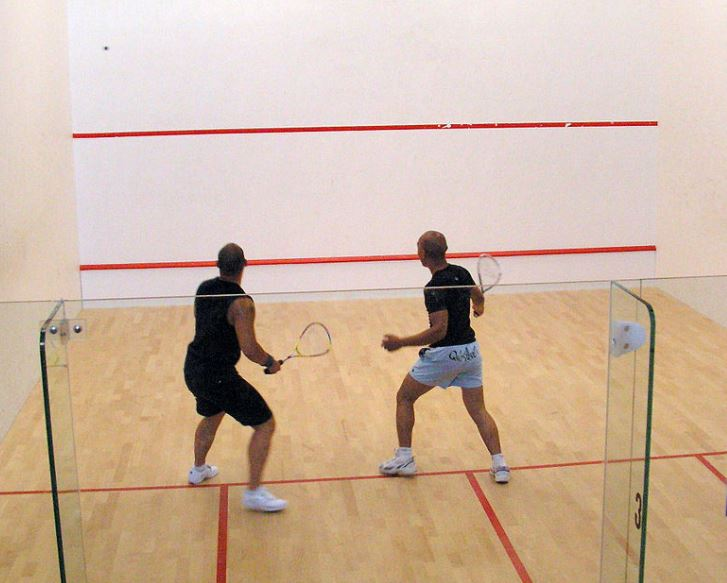">

*The RacketSports dataset was recorded from a smartwatch's accelerometer and gyroscope while players performed badminton and squash strokes ([Zenodo](https://zenodo.org/records/3742271)).*

| property | value |
|---|---|
| channels (C) | **6** — 3-axis accelerometer + 3-axis gyroscope |
| timesteps (T) | **30** — sampled at 10 Hz over ~3 seconds |
| classes | **4** — Badminton Clear, Badminton Smash, Squash Forehand Boast, Squash Backhand Boast |
| train / test | **151 / 152** trials |

Each trial is one stroke; the task is to identify the sport **and** the stroke. It is
small (fast to train) yet temporal — a good fit for spiking models. We
z-score each channel using training-set statistics, feed the 6 channels as the input
current at each of the 30 timesteps, and read out 4 class logits.

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/ch2_input_tensor.png?raw=1" width="700"/></div>

<div align="center"><em>Each trial is a 6-channel × 30-timestep array; the network reads one column (one timestep) at a time.</em></div>

**Load the data** with the helper (`aeon` downloads it automatically) and move the
tensors to the device.

In [ ]:
from snn_workshop.data import load_racket_sports

ds = load_racket_sports(normalize=True)
print(f"train {ds.X_train.shape}, test {ds.X_test.shape}")
print(f"T={ds.n_timesteps} timesteps, C={ds.n_channels} channels, "
      f"{ds.n_classes} classes: {ds.class_names}")

X_train = torch.tensor(ds.X_train, device=DEVICE)
y_train = torch.tensor(ds.y_train, device=DEVICE)
X_test = torch.tensor(ds.X_test, device=DEVICE)
y_test = torch.tensor(ds.y_test, device=DEVICE)

### What does one trial look like?

Before training, let us *see* a single swing. The 6 channels are hard to read as raw
traces, but three of them — the **accelerometer** axes — describe how the watch moves
through space. If we **integrate the acceleration twice** (acceleration → velocity →
position) we recover an approximate **3D trajectory of the swing**, and we can colour
that path by how hard the watch is accelerating at each instant.

> **Caveat.** Double-integrating a short, noisy accelerometer signal drifts, so this is
> an *illustrative* shape rather than a precise reconstruction. We remove gravity/bias
> (the per-axis mean) and a linear velocity drift to keep the path readable.

*(No task — reconstruct and plot one swing's 3D trajectory, coloured by acceleration
magnitude. Change `sample_idx` to explore other trials and classes.)*

In [ ]:
# Reconstruct the racket swing from its accelerometer signal: integrate acceleration
# twice (-> velocity -> position) to trace the watch's path through space, and colour
# the path by how hard the watch is accelerating at each moment.
# We use the *un-normalized* data here so the three accelerometer axes keep their true
# relative scale (the normalized `ds` rescales each channel independently).
ds_raw = load_racket_sports(normalize=False)

sample_idx = 0                                   # try other trials by changing this
accel = ds_raw.X_train[sample_idx, :, :3]        # channels 0-2 = 3-axis accelerometer
label = ds_raw.class_names[ds_raw.y_train[sample_idx]]

# RacketSports is sampled at 10 Hz, so each timestep is dt = 0.1 s.
plot_swing_3d(accel, dt=0.1, title=f"Swing trajectory — {label}")
plt.show()

## Training

`train_model` is a standard mini-batch Adam loop with cross-entropy loss. The only
thing that makes this "spiking" is the model — backpropagation through time and the
optimiser are exactly what you would use for any recurrent network, because the
surrogate gradient lets gradients flow through the spikes. We record **train
accuracy**, **test accuracy** (the dataset ships with its own split), and **wall-clock
training time**.

*(No task — train the SNN built from your custom-autograd spike and record its
accuracy and training time.)*

In [ ]:
@torch.no_grad()
def evaluate(model, X, y, loss_fn):
    model.eval()
    out = model(X)
    return loss_fn(out, y).item(), (out.argmax(dim=1) == y).float().mean().item()


def train_model(model, epochs=80, lr=2e-3, batch_size=32, seed=0):
    """Mini-batch Adam training with per-epoch logging.

    Returns a dict: ``history`` (per-epoch train/test loss & accuracy), the final
    ``train_acc``/``test_acc``, and ``wall`` = training-only wall-clock seconds
    (the per-epoch evaluation used for the curves is deliberately *excluded* from the
    timing, so the runtime comparison reflects training compute only).
    """
    set_seed(seed)
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    n = X_train.shape[0]
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    train_time = 0.0
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_train[idx]), y_train[idx])
            loss.backward()
            opt.step()
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        train_time += time.perf_counter() - t0

        # Per-epoch logging (not timed).
        trl, tra = evaluate(model, X_train, y_train, loss_fn)
        tel, tea = evaluate(model, X_test, y_test, loss_fn)
        history["train_loss"].append(trl); history["train_acc"].append(tra)
        history["test_loss"].append(tel); history["test_acc"].append(tea)

    return {"history": history, "train_acc": history["train_acc"][-1],
            "test_acc": history["test_acc"][-1], "wall": train_time}


# `results` collects metrics per run; `models` keeps the trained models for later cells.
results = {}
models = {}


def report(name, res):
    results[name] = res
    print(f"{name:26s}: train {res['train_acc']:.3f}  test {res['test_acc']:.3f}  "
          f"time {res['wall']:.1f}s")


# Train the SNN with the custom-autograd surrogate.
snn = DeepSNN(ds.n_channels, hidden=64, n_layers=3, n_classes=ds.n_classes,
              beta=0.9, threshold=1.0, slope=10.0, spike_fn=spike_autograd)
report("SNN (autograd)", train_model(snn))

## Baselines — MLP and GRU

To judge the SNN we train two conventional networks of matched depth/width (3 layers,
64 units). Crucially, **all three models obey the same contract**: each produces a
prediction *per timestep*, and we average those logits over time before the loss — the
exact readout you built for the SNN. They differ only in *how each timestep is computed*
and *whether information crosses time*:

- **MLP** — the *memoryless* baseline. The same small network is applied to each
  timestep's 6-channel vector independently, and the per-step predictions are averaged.
  It carries **no state across time**, so it can never integrate temporal order — its
  honest deficiency.
- **GRU** — a continuous-valued **recurrent** network, the natural non-spiking
  counterpart of our SNN: it carries a hidden state across time, reads out at every
  step, and averages. This is the apples-to-apples baseline we return to in Chapter 3.

Because the three share one input→prediction contract, every later comparison
(accuracy, training curves, and the Chapter 3 efficiency analysis) is like-for-like.

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/ch2_three_architectures.png?raw=1" width="660"/></div>

<div align="center"><em>The three models on the same input: each predicts at every timestep and pools the logits over time. The MLP is memoryless (no state across time), while the GRU and SNN carry state along the sequence.</em></div>

*(No task — train the MLP and GRU baselines.)*

In [ ]:
# Both baselines follow the SAME contract as the SNN: produce a prediction per
# timestep, then average the logits over time. They differ only in how each timestep
# is computed and whether state crosses time.
class MLP(nn.Module):
    """Memoryless per-timestep MLP: the same network is applied to each timestep's
    observation vector; per-step logits are averaged over time. No state across time."""

    def __init__(self, n_in, hidden=64, n_layers=3, n_classes=4):
        super().__init__()
        dims = [n_in] + [hidden] * (n_layers - 1)
        layers = []
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i + 1]), nn.ReLU()]
        layers += [nn.Linear(dims[-1], n_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        B, T, C = x.shape                                   # (B, T, C)
        logits_t = self.net(x.reshape(B * T, C)).reshape(B, T, -1)
        return logits_t.mean(dim=1)                         # mean over time -> (B, K)


class GRUClassifier(nn.Module):
    """3-layer GRU with a per-timestep readout averaged over time (same contract as
    the SNN); the recurrent cell is the only difference from the SNN."""

    def __init__(self, n_in, hidden=64, n_layers=3, n_classes=4):
        super().__init__()
        self.gru = nn.GRU(n_in, hidden, num_layers=n_layers, batch_first=True)
        self.readout = nn.Linear(hidden, n_classes)

    def forward(self, x):
        out, _ = self.gru(x)                                # (B, T, hidden)
        return self.readout(out).mean(dim=1)               # per-step logits, mean over time


mlp = MLP(ds.n_channels, 64, 3, ds.n_classes)
report("MLP", train_model(mlp))

gru = GRUClassifier(ds.n_channels, 64, 3, ds.n_classes)
report("GRU", train_model(gru))

# Keep the trained models for the confusion-matrix cell.
models = {"MLP": mlp, "SNN": snn, "GRU": gru}

## Results & visualizations

Each `train_model` call returned a **history** (per-epoch train/test loss and
accuracy) and a training-only **wall-clock time**. We now read those out as a summary
table and three plots. Headlines to expect:

- The **SNN reaches accuracy in the same ballpark as the baselines** — a little below
  the MLP and GRU on this small dataset, which is a good result for a spiking network
  (and Chapter 3 shows what it buys you in efficiency).
- The SNN's **training time** stands out: its Python-level unrolled time loop is slower
  than the single fused ops of the MLP/GRU. The optional bonus at the end of the
  notebook shows how to close that gap with `torch.compile`.

We also save the trained SNN to `checkpoints/` — Chapter 3 loads it.

*(No task — print the summary table and save the checkpoint.)*

In [ ]:
print("\n=== Summary ===")
print(f"{'model':22s} {'train':>7s} {'test':>7s} {'time (s)':>9s}")
for name, res in results.items():
    print(f"{name:22s} {res['train_acc']:7.3f} {res['test_acc']:7.3f} {res['wall']:9.1f}")

os.makedirs("checkpoints", exist_ok=True)
ckpt = {
    "state_dict": snn.state_dict(),
    "config": dict(n_in=ds.n_channels, hidden=64, n_layers=3, n_classes=ds.n_classes,
                   beta=0.9, threshold=1.0, slope=10.0),
    "class_names": ds.class_names,
}
torch.save(ckpt, "checkpoints/snn_racketsports.pt")
print("saved trained SNN -> checkpoints/snn_racketsports.pt")

### Training curves

For each model type, plot loss and accuracy **against epoch**, with the **training**
split solid and the **test** split dashed. These show *how* learning progresses: the
loss falling, the accuracy rising, and the gap between train and test (a read on
over-fitting — expected here, since the dataset is small).

*(No task — plot the train/test loss and accuracy curves for the SNN, MLP and GRU.)*

In [ ]:
# Loss and accuracy vs epoch (train solid, test dashed) for each model type.
for name in ["SNN (autograd)", "MLP", "GRU"]:
    plot_training_curves(results[name]["history"], title=f"{name} — training curves")
    plt.show()

### Comparing the methods directly

The per-model curves above each mix train and test on one axis. To compare *methods*
we instead overlay them on shared axes. First, **conditioned on the training set**:
how quickly and how high does each method's **training accuracy** climb? Then a single
**2×2 grid** — rows are train (top) / test (bottom), columns are loss (left) /
accuracy (right) — with every method overlaid in each panel, so differences in
optimization speed and generalization are visible at a glance.

*(No task — overlay every method's training-set accuracy on one axis.)*

In [ ]:
# Overlay every method's TRAIN accuracy on one axis to compare how fast/high each
# learns on the data it is trained on.
histories = {name: res["history"] for name, res in results.items()}
plot_metric_comparison(histories, "train_acc", ylabel="accuracy",
                       title="Training-set accuracy — all methods")
plt.show()

*(No task — 2×2 grid comparing all methods: train/test × loss/accuracy.)*

In [ ]:
# Rows: train (top) vs test (bottom). Columns: loss (left) vs accuracy (right).
# Every panel overlays all methods so they can be compared directly.
plot_method_grid(histories, title="Method comparison — loss & accuracy, train & test")
plt.show()

### Training time

Training time is a **single number per run** — the total wall-clock seconds for the
fixed number of epochs. A bar plot makes the comparison clear. The MLP and GRU are fast
because their layers are single fused ops; the SNN pays for its Python-level unrolled
time loop. That overhead is exactly what `torch.compile` removes in the optional bonus
at the end of the notebook.

*(No task — bar plot of per-run training time.)*

In [ ]:
# Single number per run: total training wall-clock time. The two SNN variants differ
# only in runtime (and tiny seeding fluctuations), not in what they learn.
plot_runtime_bar({name: res["wall"] for name, res in results.items()},
                 title=f"Training time for {len(results)} runs (same epochs)")
plt.show()

### Confusion matrices

Accuracy is one number; a **confusion matrix** shows *which* classes get confused. We
plot one per model type (MLP, SNN, GRU), normalized per true class (rows sum to 1), so
the diagonal is the per-class recall. Look for which strokes are hardest — e.g.
badminton vs squash should separate easily, while the two strokes *within* a sport may
be confused.

*(No task — compute and plot the three confusion matrices on the test set.)*

In [ ]:
def confusion(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    np.add.at(cm, (y_true, y_pred), 1)
    return cm


short_names = [n.replace("Badminton", "Bad").replace("Squash", "Squ")
                .replace("Backhand Boast", "BH").replace("Forehand Boast", "FH")
               for n in ds.class_names]

y_true = y_test.cpu().numpy()
cms, names = [], []
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).argmax(dim=1).cpu().numpy()
    cms.append(confusion(y_true, y_pred, ds.n_classes))
    names.append(name)

plot_confusion_matrices(cms, short_names, names, normalize=True)
plt.show()

# Chapter 3 — Evaluating a Spiking Neural Network

We have a trained SNN. The interesting question is no longer "how accurate is it?"
(we saw that in Chapter 2) but **"what does it actually do at inference, and why is it
efficient?"** In this chapter we:

1. look *inside* the network with **spike raster** plots,
2. measure how **sparse** its activity is, and
3. quantify the inference-time **compute cost** — the difference between
   **multiply-accumulate (MAC)** and **accumulate (AC)** operations — and compare the
   SNN with the MLP and the GRU.

> **Objective.** Build intuition for *where the efficiency of SNNs comes from*: sparse,
> binary, event-driven communication that replaces dense multiplications with sparse
> additions.

## Recover the trained network

In the full notebook the trained `snn` from Chapter 2 is still in memory. This chapter
reloads it from the checkpoint so it can also be run on its own. We then push the test
set through it and study the spikes.

**Setup.** Load the test data, rebuild the SNN, and load the trained weights.

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from snn_workshop import set_seed, get_device
from snn_workshop.data import load_racket_sports
from snn_workshop.models import DeepSNN, spike_autograd
from snn_workshop.viz import plot_spike_raster, plot_firing_rates

set_seed(0)
DEVICE = get_device()

ds = load_racket_sports(normalize=True)
X_test = torch.tensor(ds.X_test, device=DEVICE)
y_test = torch.tensor(ds.y_test, device=DEVICE)

# Rebuild the SNN and load the weights trained in Chapter 2.
ckpt_path = "checkpoints/snn_racketsports.pt"
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    snn = DeepSNN(spike_fn=spike_autograd, **ckpt["config"]).to(DEVICE)
    snn.load_state_dict(ckpt["state_dict"])
    print("loaded trained SNN from", ckpt_path)
else:
    print("WARNING: no checkpoint found -- run Chapter 2 first. Using an untrained SNN.")
    snn = DeepSNN(ds.n_channels, hidden=64, n_layers=3, n_classes=ds.n_classes,
                  spike_fn=spike_autograd).to(DEVICE)
snn.eval()

## Subtask 1 — Look inside: the spike raster

An SNN does not pass real numbers between layers — it passes **spikes**: binary events
in time. A **spike raster** shows, for every neuron (rows) and every timestep
(columns), when it fired. This is exactly how neuroscientists visualise recorded
neural activity, so it should feel familiar.

**TASK.** Take one (correctly classified) test trial, run it through the SNN with
`return_spikes=True`, and plot a raster per hidden layer. Notice how activity is
*sparse* and *distributed* — most neurons are silent at any given timestep.

In [ ]:
# Run one test trial through the SNN and visualise *when* each hidden neuron fires.
# Pick the first correctly-classified test trial so the raster matches its label.

with torch.no_grad():
    preds_all = snn(X_test).argmax(dim=1)
correct = (preds_all == y_test).nonzero(as_tuple=True)[0]
sample_idx = int(correct[0]) if len(correct) else 0

x = X_test[sample_idx:sample_idx + 1]
with torch.no_grad():
    logits, per_layer = snn(x, return_spikes=True)
pred = logits.argmax(dim=1).item()
print(f"sample {sample_idx}: true={ds.class_names[y_test[sample_idx]]}, "
      f"pred={ds.class_names[pred]}")

# TODO: draw one spike raster per hidden layer for this single trial. For each layer in
#       `per_layer`, pull its spikes onto the CPU as a (timesteps x neurons) array and
#       pass it to plot_spike_raster, giving each layer its own row of a figure that
#       shares the time axis. Notice how few neurons are active at any one timestep.
# YOUR CODE HERE

## Subtask 2 — How sparse is the network?

The raster suggested sparsity; let us quantify it. The **firing rate** of a neuron is
the fraction of timesteps on which it spikes (a number in [0, 1]). Averaged over the
test set, low firing rates mean most neurons are silent most of the time — and, as we
will see next, *silence is free* in a spiking network.

**TASK.** Compute the mean firing rate per neuron for each layer over the whole test
set and plot the distributions. Typical rates here are well below 50% — the network
has learned a sparse code.

In [ ]:
# TODO: run the whole test set through the network asking for its spikes, then turn each
#       layer's spikes into a per-neuron firing rate by averaging over both the trial and
#       the timestep dimensions. Collect these into a list `rates_per_layer`, one entry
#       per hidden layer.
# YOUR CODE HERE
for l, r in enumerate(rates_per_layer):
    print(f"layer {l + 1}: mean firing rate {r.mean():.3f} spikes/step "
          f"({100 * r.mean():.1f}% of neurons active per step)")

# TODO: visualise the per-layer firing-rate distributions (the plot_firing_rates helper
#       takes the list you just built).
# YOUR CODE HERE

## Subtask 3 — The cost of inference: MAC vs AC

Here is the crux of SNN efficiency.

- A conventional (ANN/RNN) layer computes a dense matrix–vector product. Every output
  is a sum of **weight × activation** terms — each a **multiply-accumulate (MAC)**.
  The cost is fixed by the layer dimensions and paid *in full, every time*.
- In an SNN, a presynaptic activation is a **spike: either 0 or 1**. When it is 1 the
  synapse simply **adds** its weight to the postsynaptic sum — an **accumulate (AC)**,
  *no multiply*. When it is 0 there is **nothing to do at all**. So the SNN's cost
  scales with the **number of spikes**, not the number of synapses.

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/ch3_mac_vs_ac.png?raw=1" width="680"/></div>

<div align="center"><em>The crux: a dense layer multiplies-and-accumulates every input (MAC), while an SNN only accumulates a weight where a spike occurs (AC) and skips the rest.</em></div>

Two things make this cheap: (1) an AC is several times less energy than a MAC (in a
classic 45 nm estimate, ~0.9 pJ vs ~4.6 pJ for 32-bit FP), and (2) sparsity means few
ACs are ever performed. On event-driven *neuromorphic* hardware the "do nothing for a
0" part is literal — unused synapses consume no energy.

> **A like-for-like comparison.** All three models share the same contract — predict
> per timestep, average over time — so we count operations the same way for each: over
> the full T-step sequence. The **MLP** (memoryless) and the **GRU** (recurrent) both
> do **dense MACs at every timestep**; only the SNN replaces those with **sparse ACs**
> gated by spikes. So this time the SNN is compared fairly against *both* baselines.

**TASK.** Using the measured firing rates, estimate the operation counts over the whole
sequence: the SNN's first layer sees real-valued input (MACs) while its hidden/readout
layers are spike-driven (ACs); the MLP and GRU are dense MACs at every timestep. Convert
to an energy proxy and compare. **Expect the SNN to use a fraction of the energy of
*both* the MLP and the GRU** — the headline result, now that all three do the same job.

In [ ]:
# A conventional layer computes a dense matrix-vector product: every output is a sum of
# weight x activation MULTIPLY-ACCUMULATE (MAC) operations. In an SNN, a presynaptic
# spike is binary: the synapse just ADDS its weight -> an ACCUMULATE (AC), and only when
# a spike actually occurs. So SNN cost scales with the NUMBER OF SPIKES.
T, C, H, K = ds.n_timesteps, ds.n_channels, 64, ds.n_classes
L = len(per_layer)
mean_rate = [float(r.mean()) for r in rates_per_layer]   # per hidden layer

# All three models run per timestep and pool over time; we count ops over the full
# T-step sequence so the comparison is like-for-like.
# TODO: estimate the SNN's operation counts over the full sequence. Its first layer
#       reads real-valued input, so that projection costs dense multiply-accumulates --
#       set `snn_mac`. Its remaining hidden layers and the readout are driven by spikes,
#       so they cost only accumulates, and only in proportion to how often neurons fire:
#       use the measured firing rates in `mean_rate` to scale those counts and sum them
#       into `snn_ac`.
# YOUR CODE HERE

# MLP (memoryless): the same dense net runs at EACH of the T timesteps, all MACs.
# TODO: the memoryless MLP runs its full dense stack at every timestep, so set `mlp_mac`
#       to the per-step cost of all its layers, summed across every timestep.
# YOUR CODE HERE
# GRU: several gates per recurrent layer per timestep, plus a per-step readout, all MACs.
# TODO: the GRU also runs densely at every timestep, but each recurrent layer applies
#       several gates that mix the incoming features with the carried hidden state, plus
#       a final readout. Set `gru_mac` to that per-step cost across all layers, summed
#       over every timestep.
# YOUR CODE HERE

# Energy proxy (45nm, Horowitz 2014): 32-bit FP MAC ~ 4.6 pJ, AC ~ 0.9 pJ.
E_MAC, E_AC = 4.6, 0.9
def energy(mac, ac):
    return mac * E_MAC + ac * E_AC

rows = [
    ("MLP", mlp_mac, 0.0),
    ("GRU", gru_mac, 0.0),
    ("SNN", snn_mac, snn_ac),
]
print(f"\n{'model':6s} {'MACs':>12s} {'ACs':>12s} {'energy (pJ)':>14s} {'rel.':>7s}")
base = energy(mlp_mac, 0.0)
for name, mac, ac in rows:
    e = energy(mac, ac)
    print(f"{name:6s} {mac:12,.0f} {ac:12,.0f} {e:14,.0f} {e / base:7.2f}x")

labels = [r[0] for r in rows]
energies = [energy(r[1], r[2]) for r in rows]
# TODO: draw a bar chart of `energies` per model. The values span a wide range, so a
#       logarithmic vertical axis makes the spike-driven SNN's advantage readable; label
#       each bar with its value.
# YOUR CODE HERE

## Discussion — what this does and does not show

- **vs the RNN (GRU):** the SNN does the same job — streaming temporal classification —
  for a fraction of the energy, because it replaces dense per-step MACs with sparse
  ACs. This is the result that matters and it grows with sequence length.
- **vs the MLP:** the memoryless MLP still runs a dense network at *every* timestep, so
  it too pays MACs the SNN avoids — the SNN is cheaper here as well, while additionally
  being able to integrate information across time (which the MLP cannot).
- **It is a proxy, not a hardware measurement.** Real energy depends on memory traffic,
  dataflow, precision and the actual chip; the MAC/AC counts capture the *arithmetic*
  story, which is where neuromorphic hardware wins.
- **More to explore:** asynchronicity (no global clock; neurons act on events),
  dense matrix multiply vs sparse **pop-count**/address-event routing, and trading a
  little accuracy for far fewer spikes via a **firing-rate regularizer** during
  training (try adding a small penalty on the mean spike count and re-running
  Chapter 2 — accuracy often holds while energy drops).

<div align="center"><img src="https://github.com/rwvos/bisccits-snn-workshop/blob/main/tikz_setup/img/ch3_event_driven.png?raw=1" width="700"/></div>

<div align="center"><em>Dense hardware computes on every clock tick; spiking/neuromorphic hardware works only at spike events and idles (no energy) in between.</em></div>

## Wrap-up

Across three chapters you defined a spiking neuron from its equations, trained a deep
SNN with surrogate gradients, and saw concretely where its inference efficiency comes
from. The same recipe scales to larger networks and to neuromorphic hardware, where
sparse, event-driven computation turns into real energy savings.

> **Still have time?** Continue to the optional **bonus** at the end of the notebook:
> it rewrites the spike as *forward-gradient injection* so the whole model becomes
> `torch.compile`-friendly, and measures the training speed-up.

**Thank you for joining the BISCCITS SNN workshop!**

# Bonus — Faster training: forward-gradient injection + `torch.compile`

You reached the bonus — nice. This optional chapter is about **speed**, not accuracy.

In Chapter 2 the SNN trained correctly but *slowly*: its custom `autograd.Function`
forces a "graph break", so `torch.compile` cannot fuse the unrolled time loop and each
of the 30 timesteps pays Python/kernel-launch overhead. Here we rewrite the spike so the
whole model becomes traceable, compile it, and measure the speed-up — at **identical
accuracy**, since it is the same surrogate.

> **Objective.** Express the surrogate without a custom Function, compile the model, and
> see the training time drop while accuracy stays put.

## The idea — forward-gradient injection

The fix is to express the surrogate as a **single differentiable expression** instead of
a custom Function — *forward-gradient injection*:

```python
spike = (x >= 0).float().detach() + (surr - surr.detach())
```

- **Forward:** `surr - surr.detach() == 0`, so the value is exactly the hard spike.
- **Backward:** the only non-detached term is `surr`, so the gradient is `d surr/dx` —
  our surrogate.

With `surr = x` this is the plain *straight-through estimator*; with
`surr = σ(slope·x)` we recover the smooth sigmoid surrogate from Chapter 1. Because it is
one ordinary expression (no custom Function), the whole model is now traceable, and
`torch.compile` can fuse the time loop for a large speed-up.

> **Note.** `torch.compile` needs a backend (Inductor/Triton) that ships on the Colab
> GPU runtime. On some local setups (e.g. Windows) it is unavailable; the code then
> falls back to eager mode automatically. Run this on Colab to see the speed-up.

*(No task — make sure the Chapter 2 setup is available. If you ran the whole notebook
top-to-bottom this is a no-op; if you jumped straight here in a fresh kernel it rebuilds
the data and training loop so the bonus runs on its own.)*

In [ ]:
# If you ran the whole notebook top-to-bottom, Chapter 2 already defined the data,
# DeepSNN, the autograd spike, and train_model -- reuse them. If you jumped straight
# here in a fresh kernel, rebuild that minimal setup so the bonus runs on its own.
if "train_model" not in globals():
    import os
    import time
    import torch
    import torch.nn as nn
    import matplotlib.pyplot as plt

    from snn_workshop import set_seed, get_device
    from snn_workshop.data import load_racket_sports
    from snn_workshop.models import DeepSNN, spike_autograd
    from snn_workshop.viz import plot_runtime_bar

    set_seed(0)
    DEVICE = get_device()
    print("device:", DEVICE)

    ds = load_racket_sports(normalize=True)
    X_train = torch.tensor(ds.X_train, device=DEVICE)
    y_train = torch.tensor(ds.y_train, device=DEVICE)
    X_test = torch.tensor(ds.X_test, device=DEVICE)
    y_test = torch.tensor(ds.y_test, device=DEVICE)

    @torch.no_grad()
    def evaluate(model, X, y, loss_fn):
        model.eval()
        out = model(X)
        return loss_fn(out, y).item(), (out.argmax(dim=1) == y).float().mean().item()

    def train_model(model, epochs=80, lr=2e-3, batch_size=32, seed=0):
        """Mini-batch Adam loop; returns final train/test accuracy and training-only
        wall-clock seconds (per-epoch evaluation is excluded from the timing)."""
        set_seed(seed)
        model.to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.CrossEntropyLoss()
        n = X_train.shape[0]
        train_time = 0.0
        for _ in range(epochs):
            model.train()
            perm = torch.randperm(n, device=DEVICE)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            for i in range(0, n, batch_size):
                idx = perm[i:i + batch_size]
                opt.zero_grad()
                loss = loss_fn(model(X_train[idx]), y_train[idx])
                loss.backward()
                opt.step()
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            train_time += time.perf_counter() - t0
        trl, tra = evaluate(model, X_train, y_train, loss_fn)
        tel, tea = evaluate(model, X_test, y_test, loss_fn)
        return {"train_acc": tra, "test_acc": tea, "wall": train_time}

    print("rebuilt the Chapter 2 setup for a standalone run.")
else:
    print("reusing the Chapter 2 setup already in memory.")

**TASK.** Implement `spike_fgi(x, slope)` as the single-line forward-gradient injection
above. We then run a controlled comparison: the **same architecture** trained two ways —
eagerly with the custom-autograd spike, and with `spike_fgi` under `torch.compile`.
Accuracy should match (same surrogate); the compiled model should train faster.

In [ ]:
def spike_fgi(x, slope=10.0):
    """Spike with a surrogate gradient written as one ordinary (compilable) expression.

    This produces exactly the same hard spike as the custom-autograd version in its
    forward *value*, while still letting the smooth surrogate gradient flow on the
    backward pass -- but without a custom autograd Function, so the whole model stays
    traceable by torch.compile. The idea is to combine a detached hard spike (which
    contributes the value but no gradient) with a smooth term arranged to contribute a
    gradient but no value.

    Parameters
    ----------
    x : torch.Tensor, shape (...,), float
        Shifted membrane potential (membrane minus threshold); the neuron fires where
        this is at or above zero. Any shape; handled elementwise.
    slope : float, optional
        Sharpness of the surrogate gradient (default 10.0).

    Returns
    -------
    spike : torch.Tensor, same shape as `x`, float
        The hard spike (1.0 where `x` is at or above zero, else 0.0) as its value, but
        carrying the smooth surrogate gradient on the backward pass.
    """
    # TODO: build `spike` so its value equals the hard, detached spike plus a smooth term
    #       that is zero in value but non-zero in gradient -- i.e. a smooth function of
    #       the input minus its own detached copy. Forward you get the hard spike;
    #       backward the gradient flows only through the smooth term.
    # YOUR CODE HERE
    return spike

## Takeaway

- **Same accuracy, less time.** Both models use the identical sigmoid-derivative
  surrogate, so they learn the same thing. The only difference is *how fast* — on the
  Colab GPU runtime the compiled forward-gradient-injection model trains markedly faster
  than the eager custom-autograd one. (On a CPU-only or backend-less setup the code falls
  back to eager and the two times are similar.)
- **Why it works:** removing the custom `autograd.Function` removes the graph break, so
  `torch.compile` can fuse the whole unrolled time loop into efficient kernels.
- This is the same surrogate you would now plug into larger SNNs: fast to train, ready
  for `torch.compile`.

**Thanks again for joining the BISCCITS SNN workshop!**